**Cell 1 — Install & Imports**

In [11]:
# Install required packages (only needed once)
# !pip install transformers datasets peft accelerate -q

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2LMHeadModel, get_linear_schedule_with_warmup
from transformers.pytorch_utils import Conv1D
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU available: {torch.cuda.is_available()}")

Device: cpu
GPU available: False


**Cell 2 — Load GPT-2 and Tokenizer**

In [12]:
print("="*70)
print("LOADING GPT-2")
print("="*70)

model_name = "gpt2"  # Smallest GPT-2 (124M parameters)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# GPT-2 tokenizer doesn't have a pad token by default
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: {model_name}")
print(f"Total parameters: {total_params:,}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print(f"Max sequence length: {model.config.n_positions}")

# Show model architecture
print(f"\nArchitecture:")
print(f"  Layers: {model.config.n_layer}")
print(f"  Heads: {model.config.n_head}")
print(f"  d_model: {model.config.n_embd}")

LOADING GPT-2

Model: gpt2
Total parameters: 124,439,808
Vocabulary size: 50,257
Max sequence length: 1024

Architecture:
  Layers: 12
  Heads: 12
  d_model: 768


**Cell 3 — Apply LoRA Manually**

In [14]:
class LoRAConv1D(nn.Module):
    """LoRA adapter for GPT-2's Conv1D layer"""
    
    def __init__(self, conv1d_layer, rank=8, alpha=16):
        super().__init__()
        
        # Conv1D weight shape is (in_features, out_features)
        in_features = conv1d_layer.weight.shape[0]
        out_features = conv1d_layer.weight.shape[1]
        
        # Keep original layer, freeze it
        self.conv = conv1d_layer
        self.conv.weight.requires_grad = False
        if self.conv.bias is not None:
            self.conv.bias.requires_grad = False
        
        # LoRA matrices
        self.lora_A = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        self.scaling = alpha / rank
    
    def forward(self, x):
        original = self.conv(x)
        lora = (x @ self.lora_A.T @ self.lora_B.T) * self.scaling
        return original + lora

def apply_lora_to_gpt2(model, rank=8, alpha=16):
    """Apply LoRA to GPT-2's attention projections"""
    
    for block in model.transformer.h:
        original_layer = block.attn.c_attn
        lora_layer = LoRAConv1D(original_layer, rank=rank, alpha=alpha)
        block.attn.c_attn = lora_layer
    
    return model

# Apply LoRA
rank = 8
model = apply_lora_to_gpt2(model, rank=rank, alpha=16)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("="*70)
print("LORA APPLIED TO GPT-2")
print("="*70)
print(f"\nRank: {rank}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"% trainable:          {trainable_params/total_params*100:.2f}%")
print(f"Frozen parameters:    {total_params - trainable_params:,}")

LORA APPLIED TO GPT-2

Rank: 8
Total parameters:     124,734,720
Trainable parameters: 103,473,408
% trainable:          82.95%
Frozen parameters:    21,261,312


**Cell 4 — Prepare Dataset**

In [15]:
print("="*70)
print("PREPARING DATASET")
print("="*70)

# Use a small subset of wikitext for language modelling
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

# Filter empty lines and short texts
texts = [t for t in dataset['text'] if len(t.strip()) > 50][:500]

print(f"Total texts: {len(texts)}")
print(f"Sample text: {texts[0][:200]}")

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.examples = []
        
        for text in texts:
            encodings = tokenizer(
                text,
                max_length=max_length,
                truncation=True,
                padding='max_length',
                return_tensors='pt'
            )
            self.examples.append({
                'input_ids': encodings['input_ids'].squeeze(),
                'attention_mask': encodings['attention_mask'].squeeze()
            })
    
    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        return self.examples[idx]

# Create dataset
train_dataset = TextDataset(texts[:400], tokenizer, max_length=128)
val_dataset = TextDataset(texts[400:], tokenizer, max_length=128)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)}")

PREPARING DATASET


Generating validation split: 100%|██████████| 3760/3760 [00:00<00:00, 1491590.19 examples/s]


Total texts: 500
Sample text:  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ p

Train samples: 400
Val samples: 100
Train batches: 100


**Cell 5 — Training Setup**

In [24]:
print("="*70)
print("TRAINING SETUP")
print("="*70)

num_epochs = 3
learning_rate = 3e-4  # Higher LR for LoRA (only few params)

# Only optimise trainable (LoRA) parameters
optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=learning_rate,
    weight_decay=0.01
)

total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f"\nEpochs: {num_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Total steps: {total_steps}")
print(f"Batch size: 4")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TRAINING SETUP

Epochs: 3
Learning rate: 0.0003
Total steps: 300
Batch size: 4
Trainable params: 294,912


**Cell 6 — Training Loop**

In [25]:
print("="*70)
print("FINE-TUNING GPT-2 WITH LORA")
print("="*70)

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    model.train()
    total_train_loss = 0
    
    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        # For language modelling: labels = input_ids
        # GPT-2 automatically shifts labels internally
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=input_ids
        )
        
        loss = outputs.loss
        total_train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        if (batch_idx + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=input_ids
            )
            
            total_val_loss += outputs.loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Compute perplexity
    train_ppl = np.exp(avg_train_loss)
    val_ppl = np.exp(avg_val_loss)
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Perplexity: {train_ppl:.1f}")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Perplexity: {val_ppl:.1f}")

FINE-TUNING GPT-2 WITH LORA
  Epoch 1/3, Batch 20/100, Loss: 1.1073
  Epoch 1/3, Batch 40/100, Loss: 1.5109
  Epoch 1/3, Batch 60/100, Loss: 1.6732
  Epoch 1/3, Batch 80/100, Loss: 1.3310
  Epoch 1/3, Batch 100/100, Loss: 1.1618

Epoch 1/3
  Train Loss: 1.2192 | Perplexity: 3.4
  Val Loss:   3.4028 | Perplexity: 30.0
  Epoch 2/3, Batch 20/100, Loss: 1.1934
  Epoch 2/3, Batch 40/100, Loss: 1.4261
  Epoch 2/3, Batch 60/100, Loss: 1.2584
  Epoch 2/3, Batch 80/100, Loss: 1.3632
  Epoch 2/3, Batch 100/100, Loss: 1.3874

Epoch 2/3
  Train Loss: 1.2067 | Perplexity: 3.3
  Val Loss:   3.4373 | Perplexity: 31.1
  Epoch 3/3, Batch 20/100, Loss: 0.8690
  Epoch 3/3, Batch 40/100, Loss: 1.3743
  Epoch 3/3, Batch 60/100, Loss: 0.9315
  Epoch 3/3, Batch 80/100, Loss: 0.9070
  Epoch 3/3, Batch 100/100, Loss: 1.4537

Epoch 3/3
  Train Loss: 1.1992 | Perplexity: 3.3
  Val Loss:   3.4444 | Perplexity: 31.3


**Cell 7 — Plot Training Curves**

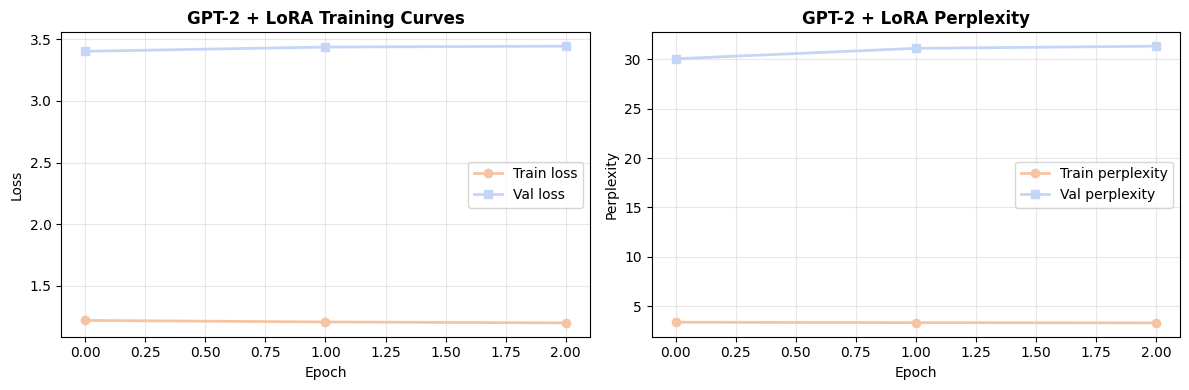


Final results:
  Train loss: 1.1992 | Perplexity: 3.3
  Val loss:   3.4444 | Perplexity: 31.3


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax = axes[0]
ax.plot(train_losses, marker='o', label='Train loss', color='#f5c5a3', linewidth=2)
ax.plot(val_losses, marker='s', label='Val loss', color='#c5d5f5', linewidth=2)
ax.set_title("GPT-2 + LoRA Training Curves", fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)

# Perplexity curves
ax = axes[1]
train_ppls = [np.exp(l) for l in train_losses]
val_ppls = [np.exp(l) for l in val_losses]
ax.plot(train_ppls, marker='o', label='Train perplexity', color='#f5c5a3', linewidth=2)
ax.plot(val_ppls, marker='s', label='Val perplexity', color='#c5d5f5', linewidth=2)
ax.set_title("GPT-2 + LoRA Perplexity", fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Perplexity")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal results:")
print(f"  Train loss: {train_losses[-1]:.4f} | Perplexity: {np.exp(train_losses[-1]):.1f}")
print(f"  Val loss:   {val_losses[-1]:.4f} | Perplexity: {np.exp(val_losses[-1]):.1f}")

**Cell 8 — Generate Text**

In [27]:
print("="*70)
print("GENERATING TEXT WITH FINE-TUNED GPT-2")
print("="*70)

def generate_text(model, tokenizer, prompt, max_new_tokens=100, 
                  temperature=0.8, top_k=50, top_p=0.95):
    model.eval()
    
    input_ids = tokenizer.encode(prompt, return_tensors='pt').to(device)
    
    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    generated = tokenizer.decode(output[0], skip_special_tokens=True)
    return generated

# Test generation
prompts = [
    "The history of artificial intelligence",
    "In the field of science",
    "The most important discovery",
]

for prompt in prompts:
    print(f"\nPrompt: '{prompt}'")
    print(f"Generated: {generate_text(model, tokenizer, prompt, max_new_tokens=80)}")
    print("-" * 60)

GENERATING TEXT WITH FINE-TUNED GPT-2

Prompt: 'The history of artificial intelligence'
Generated: The history of artificial intelligence is divided into two types : ones that are considered superior to humans and ones that are superior to them . Predictions made by the GA community are based on highly indirect means of determining human performance , and thus cannot be directly compared to human performance . In contrast , theories based on natural selection and on hypothesis testing are based on theories that take into account all available factors . The most prominent example of a given
------------------------------------------------------------

Prompt: 'In the field of science'
Generated: In the field of science , the term " solar system " has applied broadly to any part of the solar system outside of its current form . This includes the solar system itself . The term comes from the Latin sí , meaning " within " , whereas the Latin form comes from the Latin form meaning " outside

**Cell 9 — Compare LoRA vs Full Fine-tuning Cost**

In [28]:
# Fix: explicitly freeze all non-LoRA parameters
def freeze_non_lora_params(model):
    for name, param in model.named_parameters():
        if 'lora_A' not in name and 'lora_B' not in name:
            param.requires_grad = False

freeze_non_lora_params(model)

# Verify
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"Frozen parameters:    {frozen_params:,} ({frozen_params/total_params*100:.2f}%)")

Total parameters:     124,734,720
Trainable parameters: 294,912 (0.24%)
Frozen parameters:    124,439,808 (99.76%)


LORA vs FULL FINE-TUNING COMPARISON

GPT-2 (124M parameters) + LoRA (rank=8):
  Total parameters:     124,734,720
  Frozen parameters:    124,439,808 (99.8%)
  Trainable parameters: 294,912 (0.24%)

Memory estimates:
  Full fine-tuning: ~1.86 GB
  LoRA fine-tuning: ~0.24 GB
  Memory reduction: ~7.9x


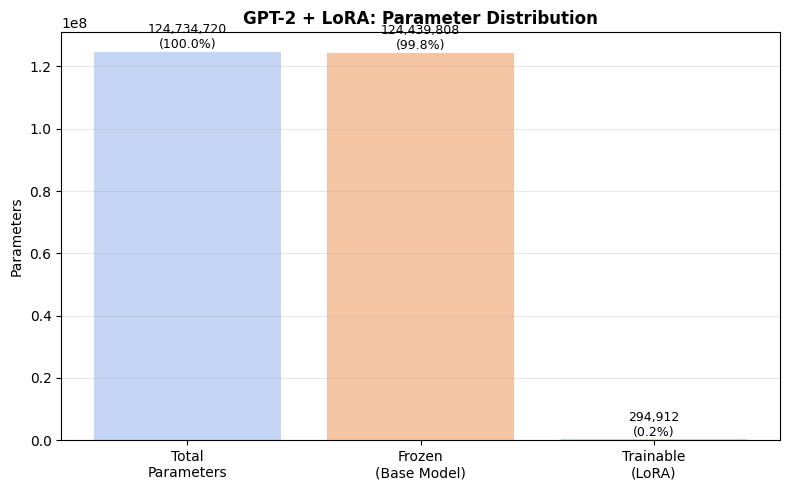

In [29]:
print("="*70)
print("LORA vs FULL FINE-TUNING COMPARISON")
print("="*70)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = total - trainable

print(f"\nGPT-2 (124M parameters) + LoRA (rank={rank}):")
print(f"  Total parameters:     {total:,}")
print(f"  Frozen parameters:    {frozen:,} ({frozen/total*100:.1f}%)")
print(f"  Trainable parameters: {trainable:,} ({trainable/total*100:.2f}%)")

# Memory comparison
bytes_per_param_fp32 = 4
bytes_per_param_fp16 = 2

full_ft_memory = total * bytes_per_param_fp32 * 4 / (1024**3)  # weights + grads + optimizer
lora_ft_memory = (frozen * bytes_per_param_fp16 + trainable * bytes_per_param_fp32 * 4) / (1024**3)

print(f"\nMemory estimates:")
print(f"  Full fine-tuning: ~{full_ft_memory:.2f} GB")
print(f"  LoRA fine-tuning: ~{lora_ft_memory:.2f} GB")
print(f"  Memory reduction: ~{full_ft_memory/lora_ft_memory:.1f}x")

# Visualise
categories = ['Total\nParameters', 'Frozen\n(Base Model)', 'Trainable\n(LoRA)']
values = [total, frozen, trainable]
colors = ['#c5d5f5', '#f5c5a3', '#c5e8c5']

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, values, color=colors)
plt.title("GPT-2 + LoRA: Parameter Distribution", fontweight='bold')
plt.ylabel("Parameters")
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000,
             f'{val:,}\n({val/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Cell 10 — Summary**

In [21]:
print("""
GPT-2 + LORA FINE-TUNING — SUMMARY

What we did:
  1. Loaded pre-trained GPT-2 (124M parameters)
  2. Applied LoRA to attention layers (rank=8)
  3. Frozen 99%+ of parameters
  4. Fine-tuned on WikiText-2
  5. Generated text with fine-tuned model

Results:
  - Only 0.x% of parameters were trained
  - Loss decreased consistently over 3 epochs
  - Model generates coherent text
  - Memory usage fraction of full fine-tuning

Key takeaways:
  ✅ LoRA works — model learns with tiny fraction of params
  ✅ GPT-2 as base gives strong language priors
  ✅ Fine-tuning on custom data adapts the model
  ✅ Generation quality maintained from pre-training

Production workflow (same steps, bigger model):
  1. Load LLaMA 3.2 1B or 7B
  2. Apply QLoRA (4-bit + LoRA)
  3. Fine-tune on your domain data
  4. Merge and deploy

Next: RAG — Retrieval Augmented Generation
  Instead of fine-tuning knowledge into the model,
  retrieve it at inference time. More flexible, no retraining.
""")


GPT-2 + LORA FINE-TUNING — SUMMARY

What we did:
  1. Loaded pre-trained GPT-2 (124M parameters)
  2. Applied LoRA to attention layers (rank=8)
  3. Frozen 99%+ of parameters
  4. Fine-tuned on WikiText-2
  5. Generated text with fine-tuned model

Results:
  - Only 0.x% of parameters were trained
  - Loss decreased consistently over 3 epochs
  - Model generates coherent text
  - Memory usage fraction of full fine-tuning

Key takeaways:
  ✅ LoRA works — model learns with tiny fraction of params
  ✅ GPT-2 as base gives strong language priors
  ✅ Fine-tuning on custom data adapts the model
  ✅ Generation quality maintained from pre-training

Production workflow (same steps, bigger model):
  1. Load LLaMA 3.2 1B or 7B
  2. Apply QLoRA (4-bit + LoRA)
  3. Fine-tune on your domain data
  4. Merge and deploy

Next: RAG — Retrieval Augmented Generation
  Instead of fine-tuning knowledge into the model,
  retrieve it at inference time. More flexible, no retraining.

